In [13]:
import matplotlib.pyplot as plt
from scipy import sparse
import numpy as np
from Hamiltonian_pricing import bs_closed_form_call, price_option_hamiltonian_bs

# Vanilla Call

In [14]:
S0 = 100
K = 120
r = 0.045
sigma = 0.25
T = 1.0

In [15]:
price, grid, values, history = price_option_hamiltonian_bs(
        S0, K, r, sigma, T, option_type="call", S_max=400, N=300, Mt=600
    )

exact = bs_closed_form_call(S0, K, r, sigma, T)

print(f"Prix Hamiltonien : {price:.6f}")
print(f"Black-Scholes exact : {exact:.6f}")
print(f"Erreur absolue : {abs(price - exact):.6f}")

Prix Hamiltonien : 4.882779
Black-Scholes exact : 4.880510
Erreur absolue : 0.002270


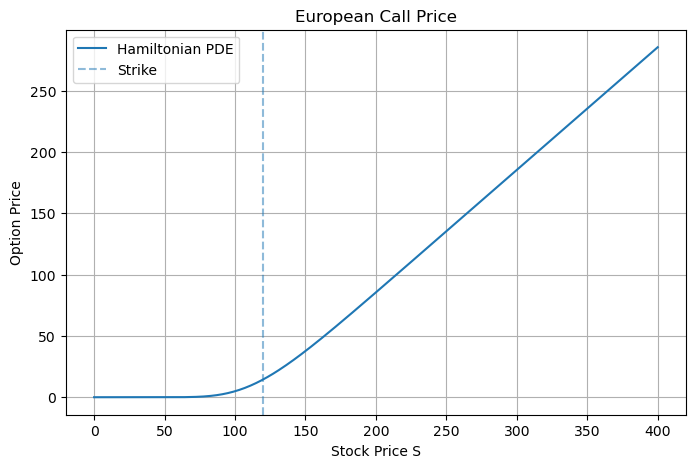

In [16]:
plt.figure(figsize=(8,5))
plt.plot(grid, values, label="Hamiltonian PDE")
plt.axvline(K, linestyle="--", alpha=0.5, label="Strike")
plt.xlabel("Stock Price S")
plt.ylabel("Option Price")
plt.title("European Call Price")
plt.legend()
plt.grid(True)
plt.show()

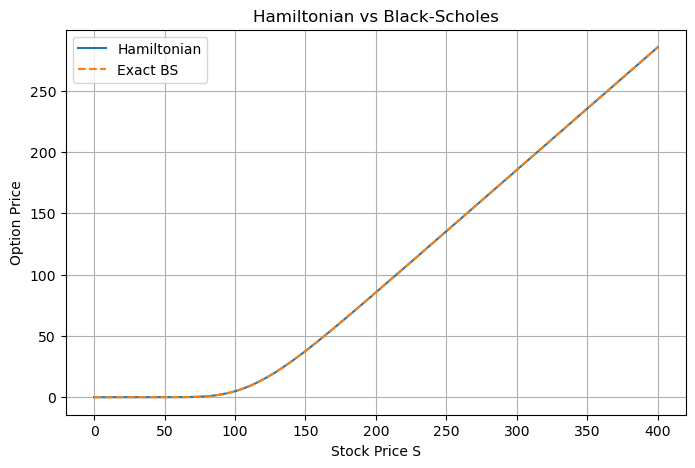

In [17]:
bs_values = np.array([
    bs_closed_form_call(s, K, r, sigma, T)
    for s in grid
])

plt.figure(figsize=(8,5))
plt.plot(grid, values, label="Hamiltonian")
plt.plot(grid, bs_values, "--", label="Exact BS")
plt.xlabel("Stock Price S")
plt.ylabel("Option Price")
plt.title("Hamiltonian vs Black-Scholes")
plt.legend()
plt.grid(True)
plt.show()

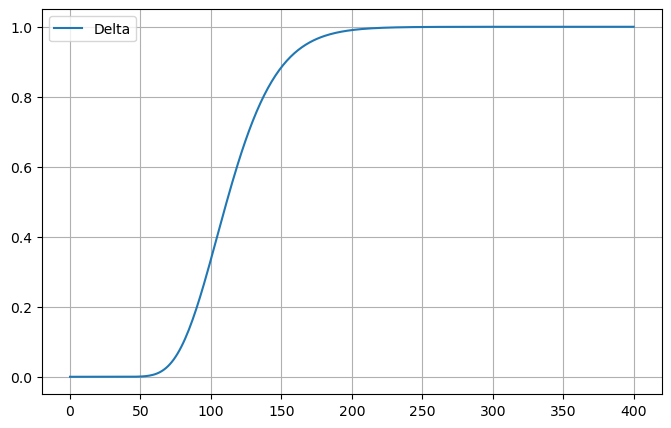

In [18]:
S_max = 400
N = 300
S = np.linspace(0.0, S_max, N)
dS = S[1] - S[0]

delta = np.gradient(values, dS)
gamma = np.gradient(delta, dS)

plt.figure(figsize=(8,5))
plt.plot(grid, delta, label="Delta")
# plt.plot(grid, gamma, label="Gamma")
plt.legend()
plt.grid(True)
plt.show()

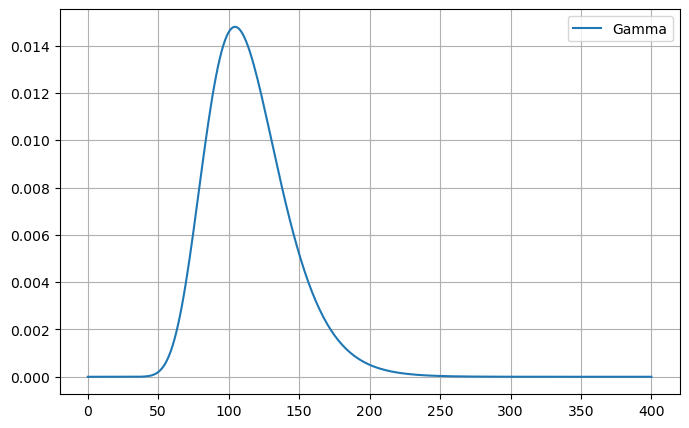

In [19]:
plt.figure(figsize=(8,5))
plt.plot(grid, gamma, label="Gamma")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
S = np.linspace(0.0, S_max, N)
Mt=600
dS = S[1] - S[0]
dt = T / Mt

# Dérivées finies sur toute la grille
upper1 = np.ones(N - 1) / (2 * dS)
lower1 = -np.ones(N - 1) / (2 * dS)
D1 = sparse.diags([lower1, upper1], offsets=[-1, 1], shape=(N, N), format="lil")

lower2 = np.ones(N - 1) / (dS**2)
diag2 = -2.0 * np.ones(N) / (dS**2)
upper2 = np.ones(N - 1) / (dS**2)
D2 = sparse.diags([lower2, diag2, upper2], offsets=[-1, 0, 1], shape=(N, N), format="lil")

# On neutralise les lignes de bord
for mat in (D1, D2):
    mat[0, :] = 0.0
    mat[-1, :] = 0.0

D1 = D1.tocsr()
D2 = D2.tocsr()

S_diag = sparse.diags(S, format="csr")
S2_diag = sparse.diags(S**2, format="csr")
I = sparse.identity(N, format="csr")

# Hamiltonien BS
H = -0.5 * sigma**2 * (S2_diag @ D2) - r * (S_diag @ D1) + r * I

In [21]:
from scipy.sparse.linalg import eigs

eigenvalues, eigenvectors = eigs(
    H,
    k=6,
    sigma=0.0,
    maxiter=20000,
    tol=1e-6
)

print(np.real(eigenvalues))

[0.05172237 0.06843553 0.045      0.045      0.09860499 0.14399779]


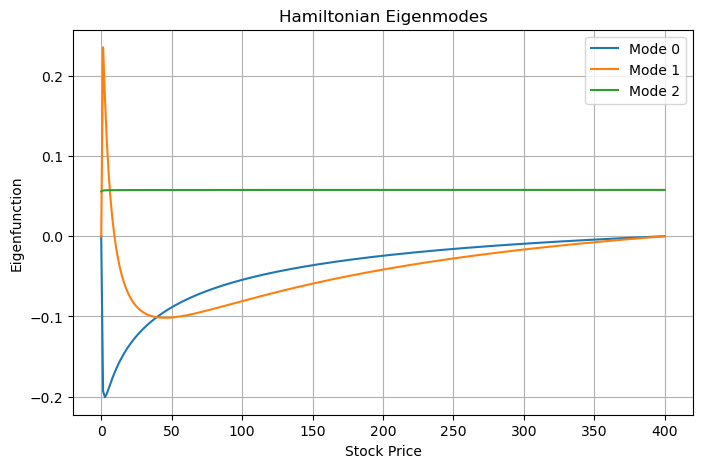

In [22]:
plt.figure(figsize=(8,5))

for i in range(3):
    plt.plot(
        grid,
        np.real(eigenvectors[:, i]),
        label=f"Mode {i}"
    )

plt.xlabel("Stock Price")
plt.ylabel("Eigenfunction")

plt.title("Hamiltonian Eigenmodes")

plt.legend()
plt.grid(True)

plt.show()

# Down-and-Out Call

In [23]:
from Hamiltonian_pricing import mc_down_and_out_call, quantum_down_and_out_call

In [24]:
barriers = [95, 90, 85, 80, 75, 70, 99, 99.5]

S0 = 100
K = 100
r = 0.05
sigma = 0.2
T = 1.0
B = 80

for B in barriers:

    ham = quantum_down_and_out_call(
        S0, K, B, T, r, sigma
    )

    mc, err = mc_down_and_out_call(
        S0, K, B, T, r, sigma
    )

    print(
        f"B={B:3f} | "
        f"Ham={ham:.4f} | "
        f"MC={mc:.4f} ± {1.96*err:.4f}"
    )

B=95.000000 | Ham=5.6361 | MC=5.7389 ± 0.0577
B=90.000000 | Ham=8.6655 | MC=8.7076 ± 0.0642
B=85.000000 | Ham=9.9493 | MC=9.9990 ± 0.0651
B=80.000000 | Ham=10.3515 | MC=10.3604 ± 0.0647
B=75.000000 | Ham=10.4382 | MC=10.4185 ± 0.0645
B=70.000000 | Ham=10.4502 | MC=10.4267 ± 0.0645
B=99.000000 | Ham=1.3674 | MC=1.6017 ± 0.0341
B=99.500000 | Ham=0.6992 | MC=0.9108 ± 0.0260
